In [1]:
library(Biostrings)
library(ggseqlogo)
library(ggplot2)

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, saveRDS, setdiff,
    table, tapply, union, unique, unsplit, which.max, which.min


Loading required package: S4Vectors

Loading required package: stats4


Attaching package: ‘S4Vectors’


The following object is masked from ‘package:utils’:

    findMatches


The following objects are masked from ‘package:base’:

    expand.grid, I, unname


Loading required package: IRanges

Loading required package: XVector

Loading required package: GenomeInfoDb


Attac

In [5]:
fa <- "/nfs/team373/dz10/test_v1_code/Sahu_et_al_custom_code/AssignTSS/RPRE_B1_SW/merged_RPRE_B1_SW_R1.tss_flanks.fasta"
#fa <- "/nfs/team373/dz10/test_v1_code/Sahu_et_al_custom_code/AssignTSS/RPRE_B4_GP5D_S1_TSL_51558/51558_R1.tss_flanks.fasta"

dna <- readDNAStringSet(fa)
dna <- toupper(as.character(dna))

L <- 120
ok <- nchar(dna) == L & !grepl("[^ACGT]", dna)
dna2 <- as.character(dna[ok])
cat("Using L =", L, "Kept", length(dna2), "Removed", sum(!ok), "\n")

Using L = 120 Kept 7438 Removed 0 


In [6]:
# 构建 position 向量：120 -> [-60..-1,+1..+60]；121 -> [-60..+60]
if (L %% 2 == 0) {
  half <- L/2
  pos <- c(-half:-1, 1:half)
} else {
  half <- (L-1)/2
  pos <- (-half):half
}

# 关键：把想显示的刻度（比如 -60,-40,-20,-1,1,20,40,60）映射到列号
want_ticks <- c(-60, -40, -20, 1, 20, 40, 60)
tick_x <- match(want_ticks, pos)  # 位置 -> 第几列（1..L）
tick_x <- tick_x[!is.na(tick_x)]
tick_lab <- want_ticks[!is.na(match(want_ticks, pos))]

# 关键：+1 在哪一列？
x_plus1 <- match(1, pos)


Scale for x is already present.
Adding another scale for x, which will replace the existing scale.


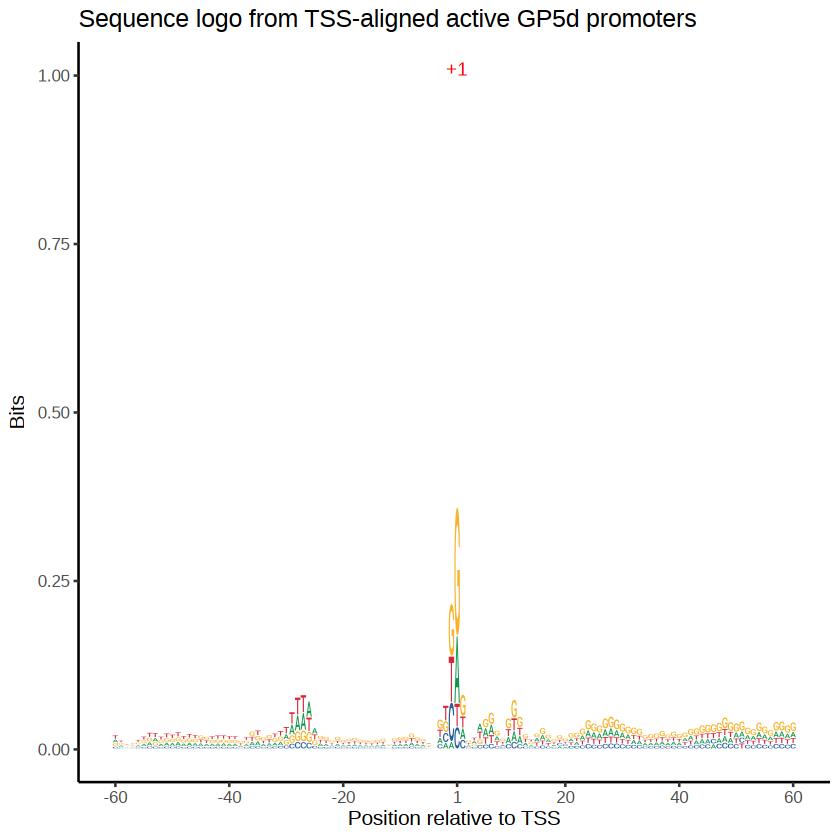

In [7]:
p <- ggseqlogo(dna2, method="bits") +
  scale_x_continuous(breaks = tick_x, labels = tick_lab) +
  labs(x="Position relative to TSS", y="Bits",
       title="Sequence logo from TSS-aligned active GP5d promoters") +
#   geom_vline(xintercept = x_plus1, linewidth = 0.5) +
  annotate("text", x = x_plus1, y =1, label = "+1", color="red", vjust=0) +
  theme_classic(base_size = 12)
p